# หลักการทำงาน


1.   Object detection (ใช้การตรวจสอบจากภาพว่ามีวัตถุดิบอะไรบ้าง)
2.   Text generation (แนะนำเมนู 3 จากวัตถุดิบ)
3.   Text generation(เลือกเมนูเพื่อดูสูตรอาหาร)
4.   Image generation (สร้างภาพตัวอย่างจากเมนูที่เลือก)



In [1]:
!pip install torch gradio timm transformers inflect phonemizer accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.4/565.4 kB 25.6 MB/s eta 0:00:00


In [2]:
# timm lib: used for using model in deep learning and make it have performance
# inflect lib: used for processing text change number into text following syntax
# phonemizer lib: used for convert text to audio
# accelerate lib: lib on hugging face, it help user can run model AI easier and have performance

In [3]:
# if you want to user new feature on model you have to install transformer directly from github
!pip install git+https://github.com/huggingface/transformers.git

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-m93efdsp
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-m93efdsp
  Resolved https://github.com/huggingface/transformers.git to commit e46c2ff32ef2c370b9214befacb0802e7ff97203
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.1 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-5.0.0.dev0-py3-none-any.whl size=11349562 sha256=af49a299f519dae84978226e3066b23507e04862dd34255faf532245fd038b7d
  Stored in directory: /tmp/pip-ephem-wheel-cache-oh9sidy4/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: huggingface-hub
    Foun

# Ingredient detection


In [4]:
'''
We will use model DETR on this stage because it easy for use
and not design starting point of object with yourself
'''
from transformers import pipeline
model = "facebook/detr-resnet-50"
od_pipe = pipeline("object-detection", model=model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [5]:
!wget https://www.shutterstock.com/image-photo/indoor-photo-flat-lay-wooden-260nw-2686836955.jpg -O vegetables.jpg
!wget https://www.pitchameat.com/wp-content/uploads/2023/10/Mainsite-3-1.jpg -O beef.jpg
!wget https://www.hongthongrice.com/home/wp-content/uploads/2017/03/rice-01.jpg -O rice.jpg

--2025-10-23 11:18:27--  https://www.shutterstock.com/image-photo/indoor-photo-flat-lay-wooden-260nw-2686836955.jpg
Resolving www.shutterstock.com (www.shutterstock.com)... 3.170.229.101, 3.170.229.62, 3.170.229.81, ...
Connecting to www.shutterstock.com (www.shutterstock.com)|3.170.229.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33509 (33K) [image/jpeg]
Saving to: ‘vegetables.jpg’

vegetables.jpg      100%[===================>]  32.72K  --.-KB/s    in 0s      

2025-10-23 11:18:27 (353 MB/s) - ‘vegetables.jpg’ saved [33509/33509]

--2025-10-23 11:18:27--  https://www.pitchameat.com/wp-content/uploads/2023/10/Mainsite-3-1.jpg
Resolving www.pitchameat.com (www.pitchameat.com)... 45.64.187.254
Connecting to www.pitchameat.com (www.pitchameat.com)|45.64.187.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 143961 (141K) [image/jpeg]
Saving to: ‘beef.jpg’

beef.jpg            100%[===================>] 140.59K  --.-KB/s    in 0.

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
def show_image(image, title):
  plt.imshow(image)
  plt.axis('off')
  plt.title(title)
  plt.show()

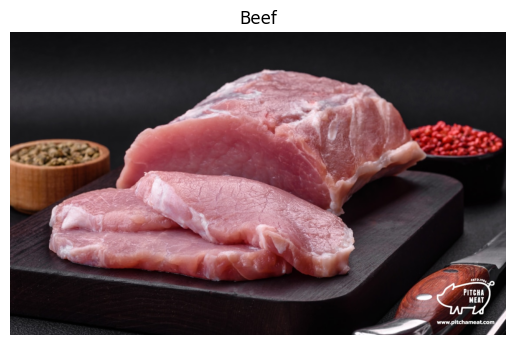

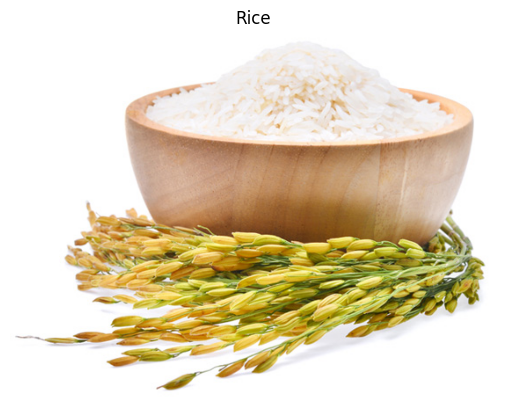

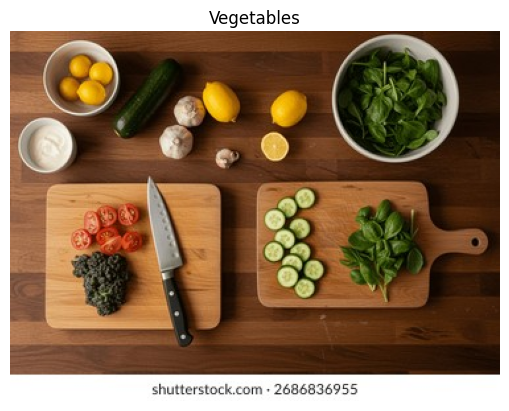

In [8]:
image_1 = Image.open("beef.jpg")
image_2 = Image.open("rice.jpg")
image_3 = Image.open("vegetables.jpg")

show_image(image_1, "Beef")

show_image(image_2, "Rice")

show_image(image_3, "Vegetables")

In [9]:
object_detection_1 = od_pipe(image_1)
object_detection_2 = od_pipe(image_2)
object_detection_3 = od_pipe(image_3)

In [10]:
print(object_detection_2)
'''
xmin,ymin คือตำแหน่งล่างซ้ายของวัตถุ
xmax,ymax คือตำแหน่งบนขวาของวัตถุ
'''

[{'score': 0.9740535020828247, 'label': 'bowl', 'box': {'xmin': 130, 'ymin': 11, 'xmax': 530, 'ymax': 248}}, {'score': 0.5905911326408386, 'label': 'dining table', 'box': {'xmin': 18, 'ymin': 195, 'xmax': 538, 'ymax': 413}}]


'\nxmin,ymin คือตำแหน่งล่างซ้ายของวัตถุ\nxmax,ymax คือตำแหน่งบนขวาของวัตถุ\n'

In [11]:
import io

In [12]:
def render_result_to_image(image,result):
  plt.figure(figsize=(16,10))
  plt.imshow(image)
  ax = plt.gca()
  for predict in result:
    x,y = predict['box']['xmin'], predict['box']['ymin']
    w = predict['box']['xmax'] - predict['box']['xmin']
    h = predict['box']['ymax'] - predict['box']['ymin']

    ax.add_patch(plt.Rectangle((x,y),w,h, fill=False, color='green', linewidth=2))
    ax.text(x,y, predict['label'], color='red', fontsize=15)
  plt.axis('off')

  # start get image that modified
  img_buf = io.BytesIO()
  plt.savefig(img_buf, format='png', bbox_inches='tight', pad_inches=0)
  img_buf.seek(0)
  modified_image = Image.open(img_buf)

  plt.close()

  return modified_image

In [13]:
result_1 = render_result_to_image(image_1, object_detection_1)
result_2 = render_result_to_image(image_2, object_detection_2)
result_3 = render_result_to_image(image_3, object_detection_3)

In [14]:
print(object_detection_1)
# ตรวจเนื้อไม่เจอ wtf

[{'score': 0.9866481423377991, 'label': 'bowl', 'box': {'xmin': 919, 'ymin': 204, 'xmax': 1140, 'ymax': 379}}, {'score': 0.6444603204727173, 'label': 'dining table', 'box': {'xmin': 0, 'ymin': 87, 'xmax': 1139, 'ymax': 686}}, {'score': 0.9948698282241821, 'label': 'bowl', 'box': {'xmin': 0, 'ymin': 242, 'xmax': 232, 'ymax': 416}}, {'score': 0.9602019786834717, 'label': 'cake', 'box': {'xmin': 243, 'ymin': 82, 'xmax': 954, 'ymax': 427}}, {'score': 0.9182835221290588, 'label': 'dining table', 'box': {'xmin': 1, 'ymin': 301, 'xmax': 1045, 'ymax': 686}}, {'score': 0.5489059090614319, 'label': 'spoon', 'box': {'xmin': 785, 'ymin': 655, 'xmax': 969, 'ymax': 695}}]


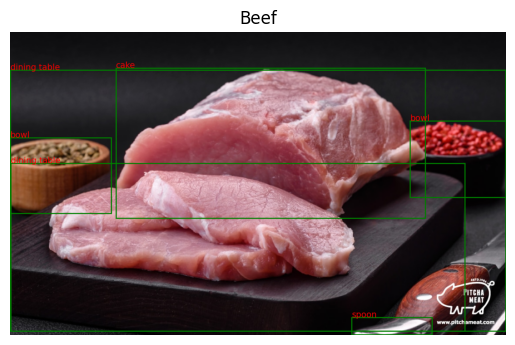

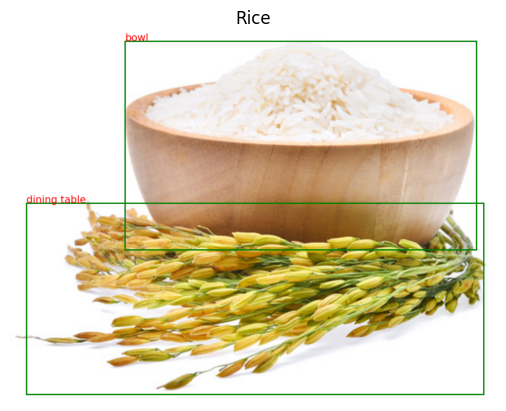

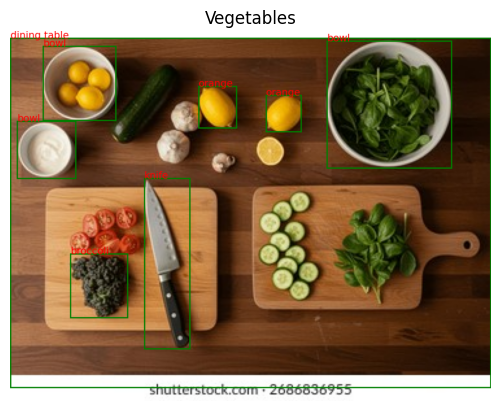

In [15]:
show_image(result_1, "Beef")
show_image(result_2, "Rice")
show_image(result_3, "Vegetables")

In [16]:
# Because there are duplicate ingrediant
# we will use Set to ensure that Input ingrediant will not have duplicate

In [17]:
Ingrediant = set()
for result in object_detection_1:
  Ingrediant.add(result['label'])
for result in object_detection_2:
  Ingrediant.add(result['label'])
for result in object_detection_3:
  Ingrediant.add(result['label'])


In [18]:
text = "We have Ingrediants: " + ", ".join(list(Ingrediant))

In [19]:
print(text)

We have Ingrediants: dining table, orange, broccoli, cake, spoon, knife, bowl


# Menu Suggestion

In [20]:
# Use a pipeline as a high-level helper
from transformers import pipeline

text_pipe = pipeline("text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0")
messages = [
    {"role": "user", "content": "Who are you?"},
]
text_pipe(messages)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': "I am a computer program designed to generate random responses to questions. I am programmed to provide personalized and unique responses to various questions, based on a user's past responses and preferences. My responses are generated based on artificial intelligence algorithms and are designed to provide personalized insights and advice to users."}]}]

**Role**

1.   user (client)
2.   assistant (AI generated)
3.   system (กำหนด บทบาทของ AI)



In [21]:
messages = [
    {'role': "system",
     'content': "You are a smart chef"
     }
]
input_text = text + '''. Please provide three menu items from these ingredients. Only three menu
                    items!!! , NO DETAILS!!!'''

In [22]:
print(input_text)

We have Ingrediants: dining table, orange, broccoli, cake, spoon, knife, bowl. Please provide three menu items from these ingredients. Only three menu
                    items!!! , NO DETAILS!!!


In [23]:
messages.append({"role":"user","content":input_text})

In [24]:
print(messages)

[{'role': 'system', 'content': 'You are a smart chef'}, {'role': 'user', 'content': 'We have Ingrediants: dining table, orange, broccoli, cake, spoon, knife, bowl. Please provide three menu items from these ingredients. Only three menu\n                    items!!! , NO DETAILS!!!'}]


In [25]:
def get_result(messages):
  prompt = text_pipe.tokenizer.apply_chat_template(
      messages,
      tokenize=False, # ensure return value will be string
      add_generation_prompt=True # let model start answer at this
  )
  outputs = text_pipe(prompt, max_new_tokens=500, do_sample=True, temperature=0.9,
       top_k=60, top_p=0.95)
  return outputs

# max_new_tokens กำหนด ความยาวของคำตอบ
# do_sample ทำให้คำตอบสุ่มคำได้
# temperature กำหนดคให้คำตอบเลือกจากความน่าจะเป็ฯสูงมั้ย ยิ่ง temperature สูงก็ยิ่งทำให้เลือกคำตอบหลากหลาย
# ทำให้คำตอบสร้างสรรค์
# top_k คือ กำหนดว่าจะสุ่มคำถัดไปจากกี่คำที่มีความน่าจะเป็นสูงสุด ยิ่งเยอะก็ยิ่งสุ่มจากหลายคำ ทำให้สร้างสรรค์ขึ่้น
# top_p คือ เลือกคำจากกลุ่มคำที่รวมกันกับกลุ่มคำแล้วมีความน่าจะเป็นเท่ากับค่าที่กำหนด ยิ่งเยอะคำตอบยิ่งหลากหลาย

In [26]:
outputs = get_result(messages)

In [27]:
print(outputs[0]['generated_text'])

<|system|>
You are a smart chef</s>
<|user|>
We have Ingrediants: dining table, orange, broccoli, cake, spoon, knife, bowl. Please provide three menu items from these ingredients. Only three menu
                    items!!! , NO DETAILS!!!</s>
<|assistant|>
1. Orange and Broccoli Salad
Ingredients:
- 1 small head of broccoli, stem removed and chopped
- 2 large oranges, peeled and sliced
- 1/4 cup of sliced almonds
- 1/4 cup of finely chopped red onions
- 1/4 cup of pine nuts
- 1/4 cup of dried cranberries
- 2 tablespoons of honey
- 2 tablespoons of lemon juice
- 2 tablespoons of olive oil
- 1 teaspoon of Dijon mustard
- Salt and pepper to taste

Instructions:
1. In a large mixing bowl, combine the chopped broccoli, sliced oranges, sliced almonds, chopped red onions, pine nuts, and dried cranberries.
2. In a small bowl, whisk together the honey, lemon juice, Dijon mustard, salt, and pepper.
3. Drizzle the honey mixture over the salad and toss to coat.
4. Add the olive oil and mix until

In [28]:
for message in messages:
  print(message['role'], ":" , message['content'])

system : You are a smart chef
user : We have Ingrediants: dining table, orange, broccoli, cake, spoon, knife, bowl. Please provide three menu items from these ingredients. Only three menu
                    items!!! , NO DETAILS!!!


In [29]:
response = outputs[0]['generated_text']
response = response.split('<|assistant|>') # because we know the answer will start with <|assistant|>
messages.append({"role":"assistant","content":response[1]})

# Suggest Recipe from user choosing

In [30]:
num = int(input("What is menu you interest: (example : 1) "))

What is menu you interest: (example : 1) 1


In [31]:
input_text = "The user has selected No." + str(num) + " Please provide the recipe for No. " + str(num) + " Only !"

In [32]:
messages.append({'role':"user",'content':input_text})

In [33]:
print(messages)

[{'role': 'system', 'content': 'You are a smart chef'}, {'role': 'user', 'content': 'We have Ingrediants: dining table, orange, broccoli, cake, spoon, knife, bowl. Please provide three menu items from these ingredients. Only three menu\n                    items!!! , NO DETAILS!!!'}, {'role': 'assistant', 'content': '\n1. Orange and Broccoli Salad\nIngredients:\n- 1 small head of broccoli, stem removed and chopped\n- 2 large oranges, peeled and sliced\n- 1/4 cup of sliced almonds\n- 1/4 cup of finely chopped red onions\n- 1/4 cup of pine nuts\n- 1/4 cup of dried cranberries\n- 2 tablespoons of honey\n- 2 tablespoons of lemon juice\n- 2 tablespoons of olive oil\n- 1 teaspoon of Dijon mustard\n- Salt and pepper to taste\n\nInstructions:\n1. In a large mixing bowl, combine the chopped broccoli, sliced oranges, sliced almonds, chopped red onions, pine nuts, and dried cranberries.\n2. In a small bowl, whisk together the honey, lemon juice, Dijon mustard, salt, and pepper.\n3. Drizzle the ho

In [34]:
outputs = get_result(messages)

In [35]:
response = outputs[0]['generated_text']
response = response.split('<|assistant|>')
messages.append({"role":"assistant","content":response[-1]})

In [36]:
print(response[-1])


Congratulations on your choice of recipe. Here's the recipe:

1. Orange and Broccoli Salad
Ingredients:
- 1 small head of broccoli, stem removed and chopped
- 2 large oranges, peeled and sliced
- 1/4 cup of sliced almonds
- 1/4 cup of finely chopped red onions
- 1/4 cup of pine nuts
- 1/4 cup of dried cranberries
- 2 tablespoons of honey
- 2 tablespoons of lemon juice
- 2 tablespoons of olive oil
- 1 teaspoon of Dijon mustard
- Salt and pepper to taste

Instructions:
1. In a large mixing bowl, combine the chopped broccoli, sliced oranges, sliced almonds, chopped red onions, pine nuts, and dried cranberries.
2. In a small bowl, whisk together the honey, lemon juice, Dijon mustard, salt, and pepper.
3. Drizzle the honey mixture over the salad and toss to coat.
4. Add the olive oil and mix until the salad is evenly coated.
5. Transfer the salad to a serving platter and chill in the refrigerator until ready to serve.

Enjoy your Orange and Broccoli Salad!


# Generated Image of selected menu

In [37]:
!pip install -U diffusers transformers

In [38]:
from diffusers import DiffusionPipeline
import torch

In [39]:
# Used stable diffusion 3.5 large model

gen_pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, use_safetensors=True, variant="fp16")
# use float16 bit instead 32 bit for saving resource and use safe_tensors for faster loading model
# load file model that low resolution by parameter varaint=fp16
gen_pipe.to('cuda') # use this model on gpu
gen_pipe.enable_attention_slicing() # open attention slicing to reduce using vram to prevent out of memory situation
gen_pipe.safety_checker = lambda images, clip_input: (images, False)

# prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
# image = gen_pipe(prompt).images[0]

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/5.14G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.fp16.saf(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [40]:
prompt = "Generated image of this menu: " + response[-1]
image = gen_pipe(prompt).images[0]

Token indices sequence length is longer than the specified maximum sequence length for this model (227 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['cup of dried cranberries - 2 tablespoons of honey - 2 tablespoons of lemon juice - 2 tablespoons of olive oil - 1 teaspoon of dijon mustard - salt and pepper to taste instructions : 1. in a large mixing bowl, combine the chopped broccoli, sliced oranges, sliced almonds, chopped red onions, pine nuts, and dried cranberries. 2. in a small bowl, whisk together the honey, lemon juice, dijon mustard, salt, and pepper. 3. drizzle the honey mixture over the salad and toss to coat. 4. add the olive oil and mix until the salad is evenly coated. 5. transfer the salad to a serving platter and chill in the refrigerator until ready to serve. enjoy your orange and broccoli salad!']
Token indices sequence length is long

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionXLPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionXLPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


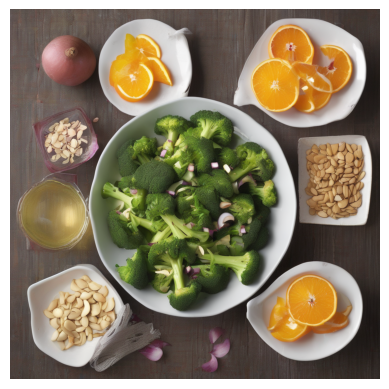

In [41]:
plt.imshow(image)
plt.axis('off')
plt.show()

# Web appliation by gradio

In [42]:
import gradio as gr

In [61]:
def generated_text(chat_history):
  prompt = text_pipe.tokenizer.apply_chat_template(chat_history,tokenize=False, add_generation_prompt=True )
  output = text_pipe(prompt, max_new_tokens=256, do_sample=True, temperature=0.8, top_k=50, top_p=0.95)
  response = output[0]['generated_text'].split('<|assistant|>')[-1]
  return response

In [62]:
def process_image(image_input, chat_history):
  od_outputs = od_pipe(image_input)
  detected = set()
  for result in od_outputs:
    detected.add(result['label'])
  text = "We have Ingrediants: " + ", ".join(list(detected)) + " Please generated three menu names with short menu names WITHOUT ingredient details"
  chat_history.append({'role':'user', 'content':text})
  rendered_image = render_result_to_image(image_input, od_outputs)
  response = generated_text(chat_history)
  chat_history.append({'role':'assistant', 'content':response})

  return rendered_image, response, gr.update(visible=True), gr.update(visible=True), gr.update(visible=True)

In [63]:
def generate_image(menu, input_number, chat_history):
  input_text = "The user has selected Menu No." + input_number + " Please provide the recipe for No. " + input_number + " Only !"
  chat_history.append({'role':'user', 'content':input_text})
  response = generated_text(chat_history)
  chat_history.append({'role':'assistant', 'content':response})
  prompt = "Generated image of this menu: " + response
  image = gen_pipe(prompt, height=512, width=512).images[0]
  return image, response

In [67]:
with gr.Blocks() as demo:
  gr.Markdown("AI Maker")
  with gr.Row():
    image_input = gr.Image(type='pil',label="Upload Image")
    image_output = gr.Image(type='pil',interactive=False,label="Detected Ingrediant")
  submit_button = gr.Button("Suggest menu / recipe Items")
  chat_history = gr.State([])
  with gr.Row():
    text_output_menu = gr.Text(label="Suggest Menu and Recipe", interactive=False)
    with gr.Column():
      input_number = gr.Text(label="Please choose one menu from these...", visible=False)
      recipe_button = gr.Button("Generated Image", visible=False)
    image_gen = gr.Image(type='pil',interactive=False,label="Generated Image", visible=False)
  submit_button.click(process_image, inputs=[image_input, chat_history], outputs=[image_output,text_output_menu, input_number, recipe_button, image_gen])
  recipe_button.click(generate_image, inputs=[text_output_menu, input_number, chat_history], outputs=[image_gen, text_output_menu])

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://794f2e57bf036dea50.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
